/tmp/ipykernel_3647/2230936124.py:21: RuntimeWarning: invalid value encountered in arccos
  hour_angle = np.arccos(-np.tan(np.radians(latitude)) * np.tan(np.radians(declination)))


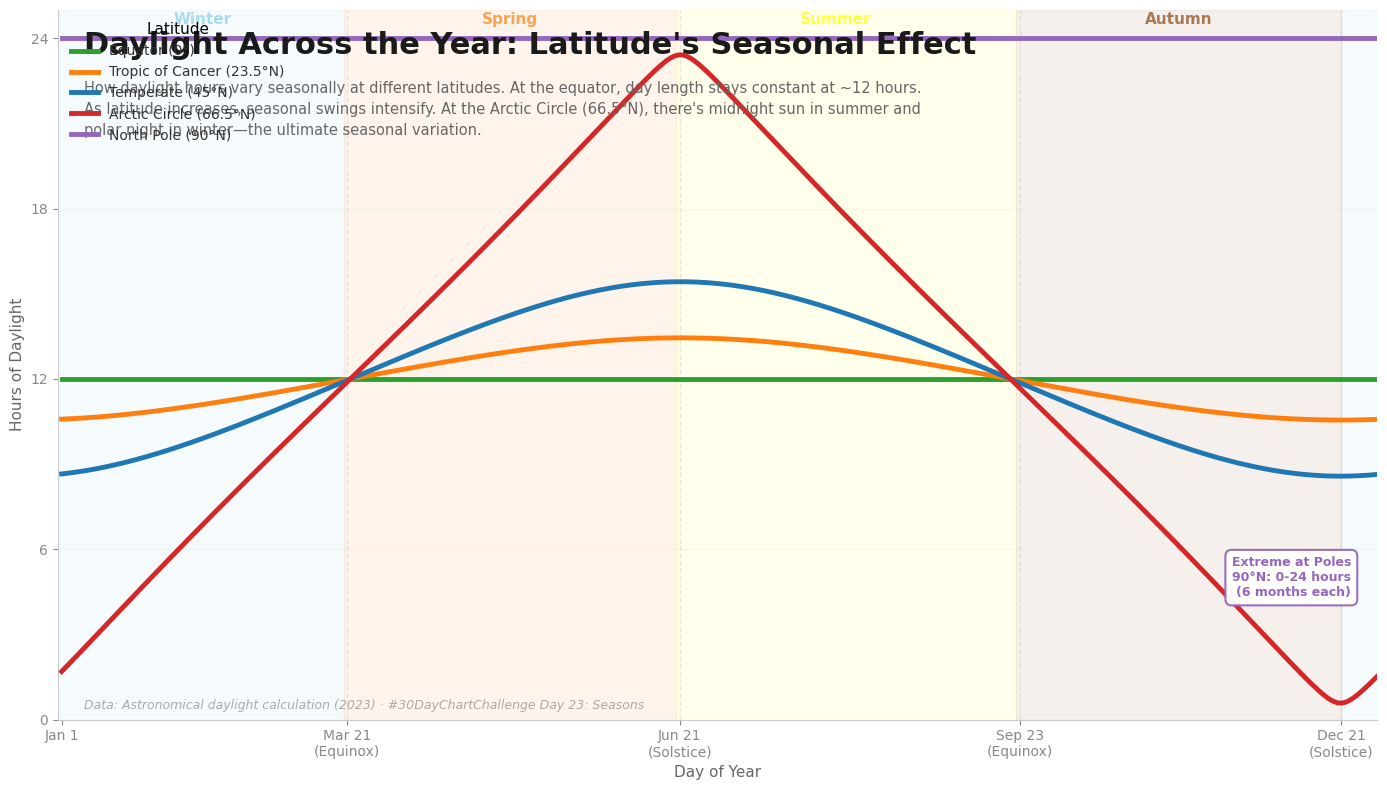

In [1]:
"""
#30DayChartChallenge — Day 23: Seasons
"Daylight Across the Year: Latitude's Seasonal Effect" — cyclical seasonal variation
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Daily daylight hours by season across different latitudes (2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Hours of daylight by day of year at different latitudes
# ---------------------------------------------------------------------------
# Calculate approximate daylight hours using astronomical formula
def daylight_hours(day_of_year, latitude):
    """Calculate daylight hours for a given day and latitude"""
    # Simplified formula based on seasonal variation
    declination = 23.44 * np.sin(np.radians((day_of_year - 80.86) * 360 / 365.25))
    hour_angle = np.arccos(-np.tan(np.radians(latitude)) * np.tan(np.radians(declination)))
    daylight = 24 * hour_angle / np.pi
    return max(0, min(24, daylight))

days = np.arange(1, 366)
latitudes_list = [
    ("Equator (0°)", 0),
    ("Tropic of Cancer (23.5°N)", 23.5),
    ("Temperate (45°N)", 45),
    ("Arctic Circle (66.5°N)", 66.5),
    ("North Pole (90°N)", 90)
]

df_data = {"Day": days}
for label, lat in latitudes_list:
    df_data[label] = [daylight_hours(d, lat) for d in days]

df = pd.DataFrame(df_data)

# ---------------------------------------------------------------------------
# 2. PLOT — Seasonal variation across latitudes
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Colors for each latitude band
colors = ["#2ca02c", "#ff7f0e", "#1f77b4", "#d62728", "#9467bd"]

# Plot lines for each latitude
for i, (label, lat) in enumerate(latitudes_list):
    ax.plot(df["Day"], df[label], linewidth=3.5, color=colors[i], label=label, zorder=3)

# Shade seasonal regions
ax.axvspan(79, 171, alpha=0.08, color="#ff7f0e", zorder=0)   # Spring (Mar 20 - Jun 20)
ax.axvspan(171, 265, alpha=0.08, color="#ffff00", zorder=0)  # Summer (Jun 21 - Sep 22)
ax.axvspan(265, 355, alpha=0.08, color="#8b4513", zorder=0)  # Autumn (Sep 23 - Dec 21)
ax.axvspan(355, 365, alpha=0.08, color="#87ceeb", zorder=0)  # Winter (Dec 22 - Dec 31)
ax.axvspan(0, 79, alpha=0.08, color="#87ceeb", zorder=0)     # Winter (Jan 1 - Mar 19)

# Season labels
season_centers = [40, 125, 215, 310]
season_names = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = ["#87ceeb", "#ff7f0e", "#ffff00", "#8b4513"]

for center, name, color in zip(season_centers, season_names, season_colors):
    ax.text(center, 24.5, name, fontsize=11, fontweight="bold", color=color, ha="center", alpha=0.7)

# Day of year to date conversion helper
date_labels = {
    1: "Jan 1",
    80: "Mar 21",
    172: "Jun 21",
    266: "Sep 23",
    355: "Dec 21"
}

# Add vertical lines for equinoxes and solstices
ax.axvline(x=80, color="#cccccc", linestyle="--", linewidth=1, alpha=0.5, zorder=1)
ax.axvline(x=172, color="#cccccc", linestyle="--", linewidth=1, alpha=0.5, zorder=1)
ax.axvline(x=266, color="#cccccc", linestyle="--", linewidth=1, alpha=0.5, zorder=1)
ax.axvline(x=355, color="#cccccc", linestyle="--", linewidth=1, alpha=0.5, zorder=1)

# Minimal styling
ax.set_xlim(0, 365)
ax.set_ylim(0, 25)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, axis="y", zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("Day of Year", fontsize=11, color="#666666", fontweight="500")
ax.set_ylabel("Hours of Daylight", fontsize=11, color="#666666", fontweight="500")
ax.set_xticks([1, 80, 172, 266, 355])
ax.set_xticklabels(["Jan 1", "Mar 21\n(Equinox)", "Jun 21\n(Solstice)", "Sep 23\n(Equinox)", "Dec 21\n(Solstice)"],
                   fontsize=9, color="#888888")
ax.set_yticks([0, 6, 12, 18, 24])
ax.tick_params(colors="#888888", labelsize=10)

# Legend
ax.legend(loc="upper left", fontsize=10, frameon=False, title="Latitude",
          title_fontsize=11, labelcolor="#333333")

# Title & subtitle
ax.text(0.02, 0.97, "Daylight Across the Year: Latitude's Seasonal Effect",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "How daylight hours vary seasonally at different latitudes. At the equator, day length stays constant at ~12 hours.\n"
        "As latitude increases, seasonal swings intensify. At the Arctic Circle (66.5°N), there's midnight sun in summer and\n"
        "polar night in winter—the ultimate seasonal variation.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Key insight
ax.text(0.98, 0.20, "Extreme at Poles\n90°N: 0-24 hours\n(6 months each)",
        fontsize=9, color="#9467bd", fontweight="bold", transform=ax.transAxes, 
        ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff", edgecolor="#9467bd", linewidth=1.5, alpha=0.95))

# Source
ax.text(0.02, 0.01,
        "Data: Astronomical daylight calculation (2023) · #30DayChartChallenge Day 23: Seasons",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day23_seasons.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()